# Insurance Analytics
### Descriptive, Diagnostic, Predictive, and Prescriptive Analytics


***

## Environment Setup and Configuration


In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings


warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#dddddd'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE = {
    'primary': '#1d3557',   
    'secondary': '#457b9d',   
    'accent': '#e63946',      
    'light': '#f1faee',       
    'highlight': '#a8dadc'    
}
sns.set_palette([PALETTE['primary'], PALETTE['secondary'], PALETTE['highlight'], PALETTE['accent']])

print("Environment successfully configured with custom visualization style.")

Environment successfully configured with custom visualization style.


## 1. DATA LOADING

In [ ]:
from src.data_loader import load_data

df = load_data("../data/insurance_data.txt")

df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


## 2. DATA SUMMARIZATION

In [50]:
#Check dtypes properly
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[us]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               1000098 non-null  str           
 5   LegalType                 1000098 non-null  str           
 6   Title                     1000098 non-null  str           
 7   Language                  1000098 non-null  str           
 8   Bank                      854137 non-null   str           
 9   AccountType               959866 non-null   str           
 10  MaritalStatus             991839 non-null   str           
 11  Gender                    990562 non-null   str           
 1

,UnderwrittenCoverID,PolicyID,TransactionMonth,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1000098,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,2015-02-28 10:49:29.147424,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
min,1.000000e+00,1.400000e+01,2013-10-01 00:00:00,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,2015-01-01 00:00:00,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2015-04-01 00:00:00,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,2015-06-01 00:00:00,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,2015-08-01 00:00:00,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05
std,6.329371e+04,5.290039e+03,NaN,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03


In [47]:
#Check dtypes properly
df.dtypes.value_counts()

str        36
float64    11
int64       4
bool        1
Name: count, dtype: int64

In [48]:
#Convert date column:
df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"])

In [49]:
df.to_csv(
    "../data/insurance_data.csv",
    index=False
)

## 3. DATA QUALITY ASSESSMENT

#### 3.1 Missing values

In [51]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
Rebuilt                     641901
Converted                   641901
WrittenOff                  641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
VehicleType                    552
make                           552
mmcode                         552
Model                          552
Cylinders                      552
bodytype                       552
kilowatts                      552
NumberOfDoors                  552
VehicleIntroDate               552
cubiccapacity                  552
CapitalOutstanding               2
dtype: int64

#### 3.2 Handling strategy

Categorical → fill with "Unknown"
Numeric → median imputation

In [52]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

#### 3.3 Duplicates


In [53]:
df.duplicated().sum()

df = df.drop_duplicates()

## 4. FEATURE ENGINEERING

In [31]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]
df["HasClaim"] = df["TotalClaims"] > 0

## 5. Descriptive Analytics

In [63]:
total_premiums = df["TotalPremium"].sum()
total_claims = df["TotalClaims"].sum()

overall_loss_ratio = total_claims / total_premiums
claim_rate = (df["TotalClaims"] > 0).mean()

metrics = pd.DataFrame({
    "Metric": [
        "Total Premiums",
        "Total Claims",
        "Loss Ratio",
        "Claim Frequency"
    ],
    "Value": [
        total_premiums,
        total_claims,
        overall_loss_ratio,
        claim_rate
    ]
})

metrics

,Metric,Value
0,Total Premiums,6.191156e+07
1,Total Claims,6.486755e+07
2,Loss Ratio,1.047745e+00
3,Claim Frequency,2.787727e-03


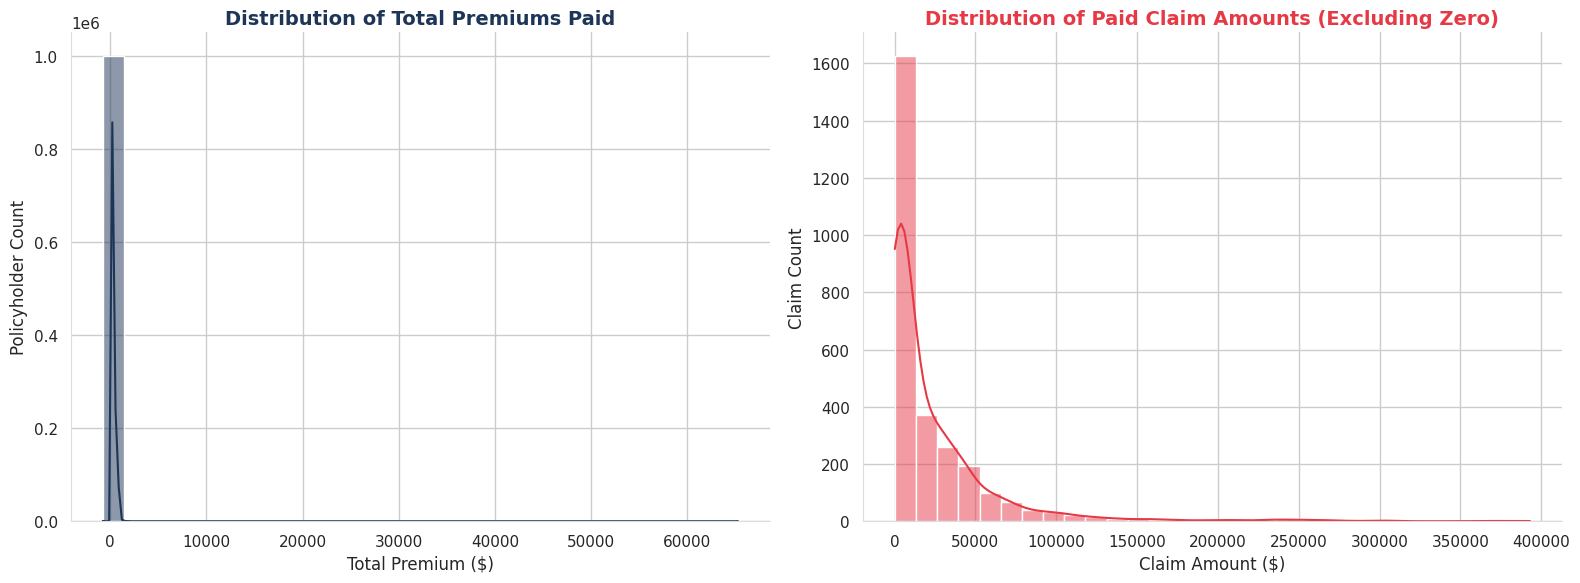

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of Total Premiums
sns.histplot(df['TotalPremium'], kde=True, color=PALETTE['primary'], ax=axes[0], bins=30)
axes[0].set_title('Distribution of Total Premiums Paid', fontsize=14, fontweight='bold', color=PALETTE['primary'])
axes[0].set_xlabel('Total Premium ($)', fontsize=12)
axes[0].set_ylabel('Policyholder Count', fontsize=12)

# Distribution of Claims Paid (Excluding 0 claims)
sns.histplot(df[df['TotalClaims'] > 0]['TotalClaims'], kde=True, color=PALETTE['accent'], ax=axes[1], bins=30)
axes[1].set_title('Distribution of Paid Claim Amounts (Excluding Zero)', fontsize=14, fontweight='bold', color=PALETTE['accent'])
axes[1].set_xlabel('Claim Amount ($)', fontsize=12)
axes[1].set_ylabel('Claim Count', fontsize=12)

plt.tight_layout()
plt.show()

## Geographic & Vehicle Insights

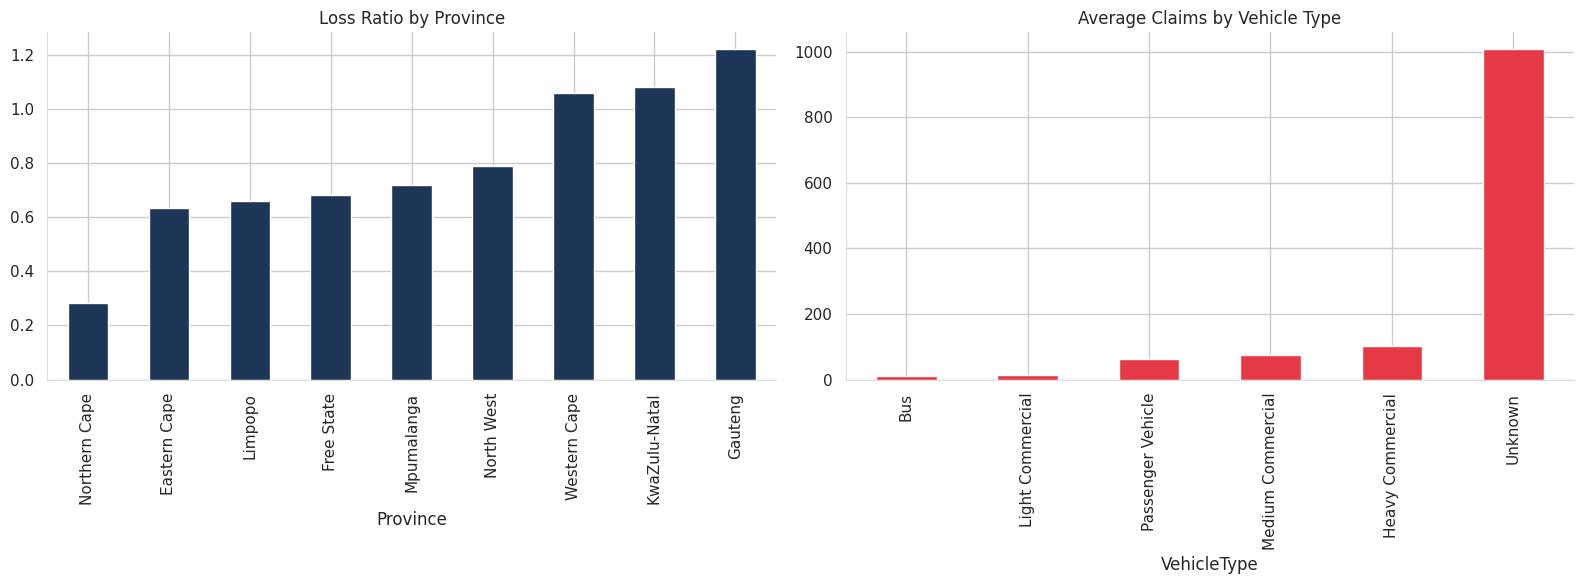

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

province_lr = df.groupby("Province")["TotalClaims"].sum() / df.groupby("Province")["TotalPremium"].sum()

province_lr.sort_values().plot(kind="bar", ax=axes[0], color=PALETTE["primary"])
axes[0].set_title("Loss Ratio by Province")

vehicle_lr = df.groupby("VehicleType")["TotalClaims"].mean()
vehicle_lr.sort_values().plot(kind="bar", ax=axes[1], color=PALETTE["accent"])
axes[1].set_title("Average Claims by Vehicle Type")

plt.tight_layout()
plt.show()

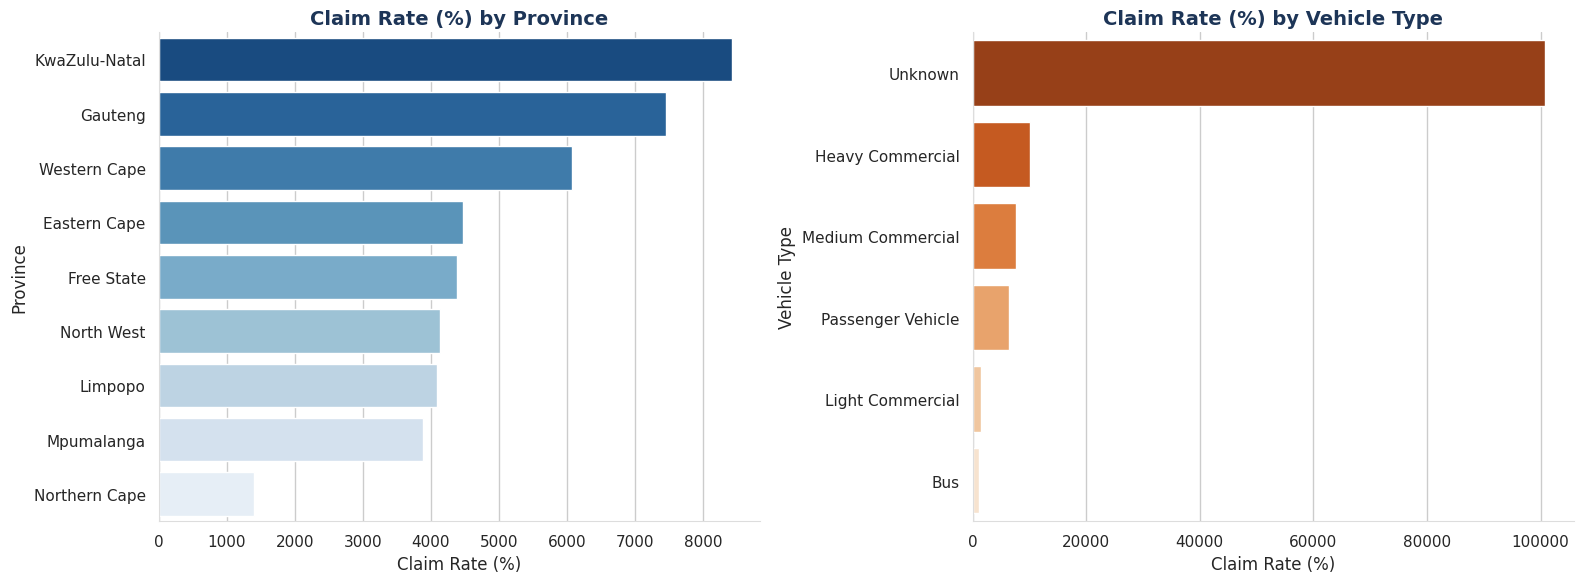

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Claim Rate by Province
prov_claims = df.groupby('Province')['TotalClaims'].mean().reset_index()
prov_claims['TotalClaims'] *= 100  # Convert to %
prov_claims = prov_claims.sort_values(by='TotalClaims', ascending=False)

sns.barplot(x='TotalClaims', y='Province', data=prov_claims, palette="Blues_r", ax=axes[0])
axes[0].set_title('Claim Rate (%) by Province', fontsize=14, fontweight='bold', color=PALETTE['primary'])
axes[0].set_xlabel('Claim Rate (%)', fontsize=12)
axes[0].set_ylabel('Province', fontsize=12)

# Claim Rate by Vehicle Type
veh_claims = df.groupby('VehicleType')['TotalClaims'].mean().reset_index()
veh_claims['TotalClaims'] *= 100  # Convert to %
veh_claims = veh_claims.sort_values(by='TotalClaims', ascending=False)

sns.barplot(x='TotalClaims', y='VehicleType', data=veh_claims, palette="Oranges_r", ax=axes[1])
axes[1].set_title('Claim Rate (%) by Vehicle Type', fontsize=14, fontweight='bold', color=PALETTE['primary'])
axes[1].set_xlabel('Claim Rate (%)', fontsize=12)
axes[1].set_ylabel('Vehicle Type', fontsize=12)

plt.tight_layout()
plt.show()

## 3. Diagnostic Analytics

### Correlation Analysis

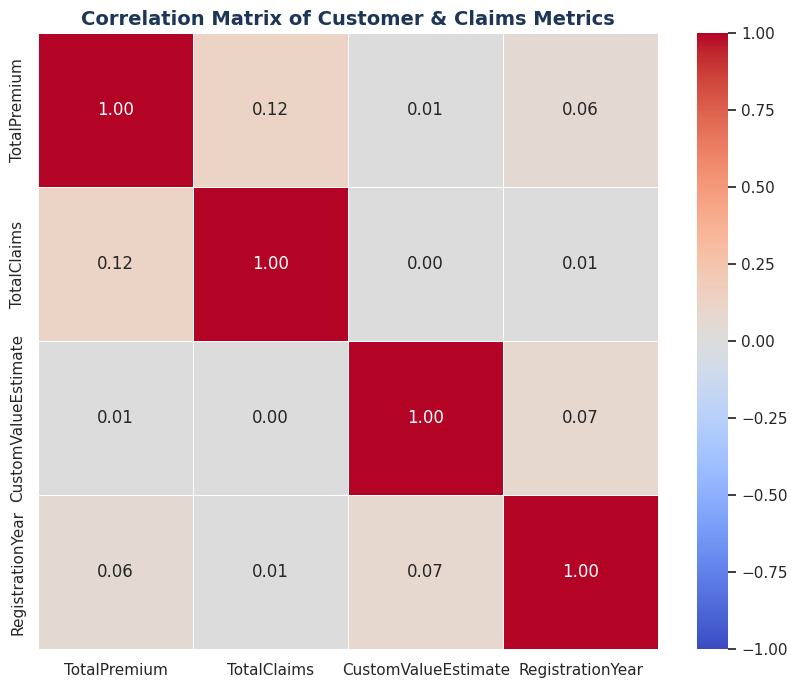

In [80]:
numerical_cols = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 'RegistrationYear']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Customer & Claims Metrics', fontsize=14, fontweight='bold', color=PALETTE['primary'])
plt.show()

## Loss Ratio by Gender / Province / VehicleType

In [98]:
df["LossRatio"] = np.where(
    df["TotalPremium"] > 0,
    df["TotalClaims"] / df["TotalPremium"],
    np.nan
)

df_clean = df[df["LossRatio"].notna() & np.isfinite(df["LossRatio"])]

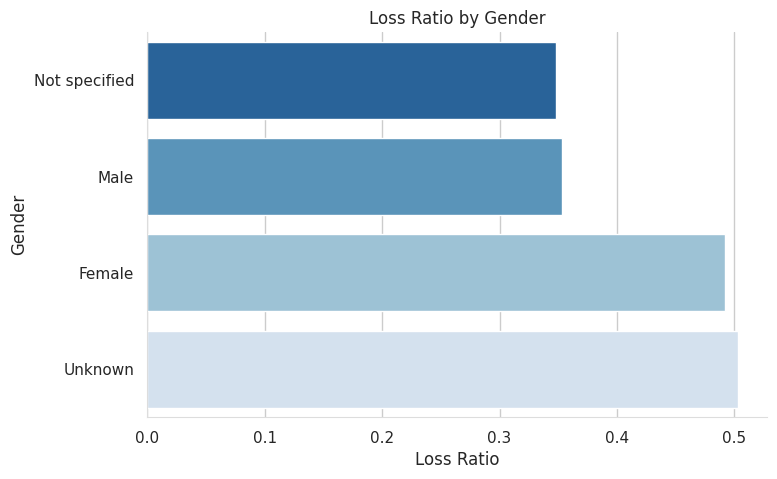

In [99]:

plt.figure(figsize=(8,5))

gender_lr = df_clean.groupby("Gender")["LossRatio"].mean().sort_values()

sns.barplot(x=gender_lr.values, y=gender_lr.index, palette="Blues_r")

plt.title("Loss Ratio by Gender")
plt.xlabel("Loss Ratio")
plt.ylabel("Gender")
plt.show()

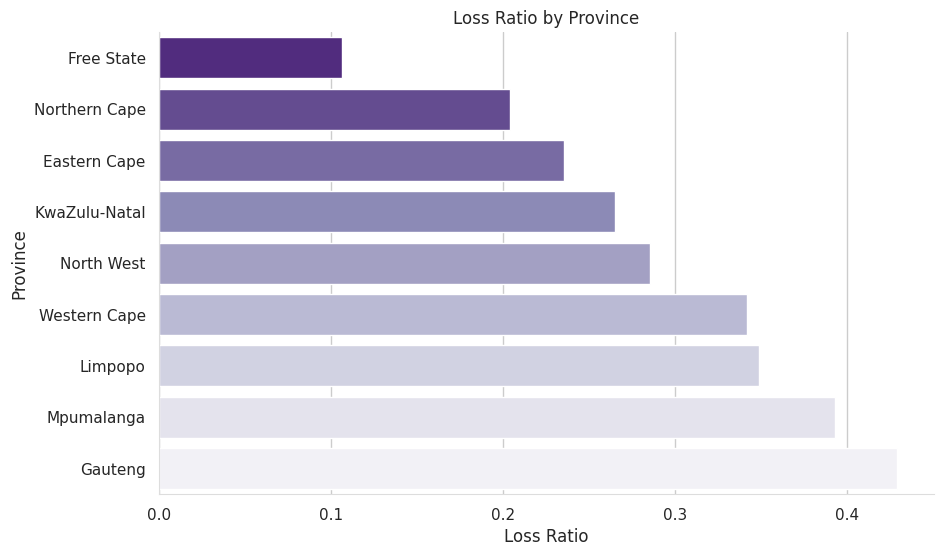

In [100]:
plt.figure(figsize=(10,6))

province_lr = df_clean.groupby("Province")["LossRatio"].mean().sort_values()

sns.barplot(x=province_lr.values, y=province_lr.index, palette="Purples_r")

plt.title("Loss Ratio by Province")
plt.xlabel("Loss Ratio")
plt.ylabel("Province")
plt.show()

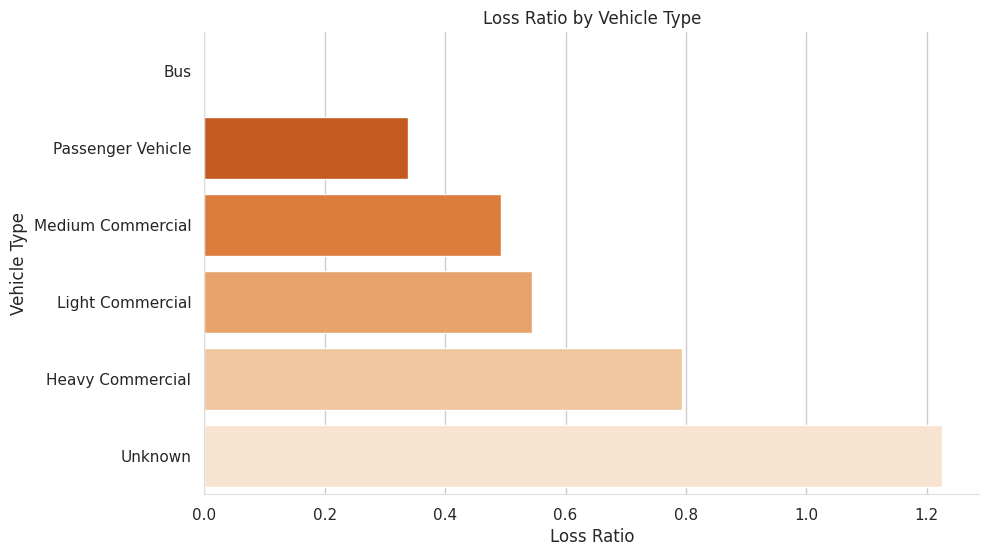

In [101]:
plt.figure(figsize=(10,6))

vehicle_lr = df_clean.groupby("VehicleType")["LossRatio"].mean().sort_values()

sns.barplot(x=vehicle_lr.values, y=vehicle_lr.index, palette="Oranges_r")

plt.title("Loss Ratio by Vehicle Type")
plt.xlabel("Loss Ratio")
plt.ylabel("Vehicle Type")
plt.show()

### Temporal Trend

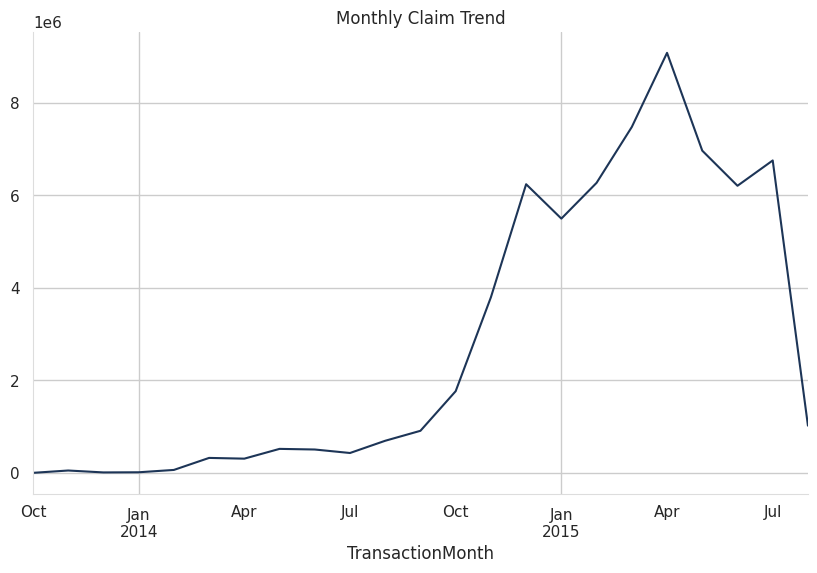

In [102]:
monthly_trend = df.groupby(df["TransactionMonth"].dt.to_period("M"))["TotalClaims"].sum()

monthly_trend.plot()
plt.title("Monthly Claim Trend")
plt.show()